<a href="https://colab.research.google.com/github/roalddalhwriter/isro/blob/main/Supervised824.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install spectral numpy scipy matplotlib scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 5.7 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from scipy.spatial.distance import cdist
import spectral

HDR_PATH = '/content/drive/MyDrive/SupervisedHyperspectral/IcelandAviris824/quack 824.hdr'
IMG_PATH = '/content/drive/MyDrive/SupervisedHyperspectral/IcelandAviris824/quack 824'

ASCII_FILES = [
    '/content/drive/MyDrive/SupervisedHyperspectral/IcelandAviris824/black.txt',
    '/content/drive/MyDrive/SupervisedHyperspectral/IcelandAviris824/white region inside cone.txt',
    '/content/drive/MyDrive/SupervisedHyperspectral/IcelandAviris824/water.txt',
    '/content/drive/MyDrive/SupervisedHyperspectral/IcelandAviris824/vegitation.txt',
    '/content/drive/MyDrive/SupervisedHyperspectral/IcelandAviris824/spatters.txt',
]
CLASS_NAMES = ['Black', 'WhiteInnerCone', 'Water', 'Vegetation', 'Spatters']

In [14]:
import spectral
import numpy as np

img  = spectral.open_image(HDR_PATH)
data = img.load().astype(np.float32)          # shape: (rows, cols, bands)
img_wavelengths = np.array(img.metadata['wavelength'], dtype=np.float32)

rows, cols, bands = data.shape
print(f"Image shape : {rows} x {cols} x {bands} bands")
print(f"Wavelength range: {img_wavelengths[0]:.1f} – {img_wavelengths[-1]:.1f} nm")

Image shape : 631 x 347 x 425 bands
Wavelength range: 377.1 – 2500.8 nm


In [15]:
def parse_envi_ascii(filepath):
    """
    Reads an ENVI ASCII plot file.
    Returns (wavelengths, mean_spectrum) both as 1-D numpy arrays.
    """
    data_rows = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # data lines start with a digit or a space followed by a digit
            if line[0].isdigit() or (line[0] == ' ' and line.lstrip()[0].isdigit()):
                vals = [float(x) for x in line.split()]
                data_rows.append(vals)

    arr         = np.array(data_rows, dtype=np.float32)
    wavelengths = arr[:, 0]          # column 0 = wavelength
    spectra     = arr[:, 1:]         # columns 1..N = individual pixel spectra
    mean_spec   = spectra.mean(axis=1)
    print(f"  {filepath.split('/')[-1]} → {spectra.shape[1]} pixels, "
          f"{len(wavelengths)} wavelength points")
    return wavelengths, mean_spec

print("Parsing ASCII files …")
ascii_wl_list, raw_refs = [], []
for fp in ASCII_FILES:
    wl, spec = parse_envi_ascii(fp)
    ascii_wl_list.append(wl)
    raw_refs.append(spec)
print("Done.")

Parsing ASCII files …
  black.txt → 4 pixels, 425 wavelength points
  white region inside cone.txt → 13 pixels, 425 wavelength points
  water.txt → 22 pixels, 425 wavelength points
  vegitation.txt → 17 pixels, 425 wavelength points
  spatters.txt → 21 pixels, 425 wavelength points
Done.


In [16]:
def align_to_image_bands(ascii_wl, ascii_spec, img_wl):
    """Interpolate ascii_spec so it matches the image's band wavelengths."""
    # Only interpolate within the overlapping range (no extrapolation)
    aligned = np.interp(img_wl, ascii_wl, ascii_spec,
                        left=np.nan, right=np.nan)
    return aligned

aligned_refs = []
for i, (wl, spec) in enumerate(zip(ascii_wl_list, raw_refs)):
    aligned = align_to_image_bands(wl, spec, img_wavelengths)
    nan_count = np.isnan(aligned).sum()
    if nan_count > 0:
        print(f"  [{CLASS_NAMES[i]}] WARNING: {nan_count} bands outside ASCII "
              f"wavelength range → filling with band mean")
        band_mean = np.nanmean(aligned)
        aligned   = np.where(np.isnan(aligned), band_mean, aligned)
    aligned_refs.append(aligned)

aligned_refs = np.array(aligned_refs)   # shape: (n_classes, bands)
print(f"\nReference matrix shape: {aligned_refs.shape}  ← (classes × bands)")


Reference matrix shape: (5, 425)  ← (classes × bands)


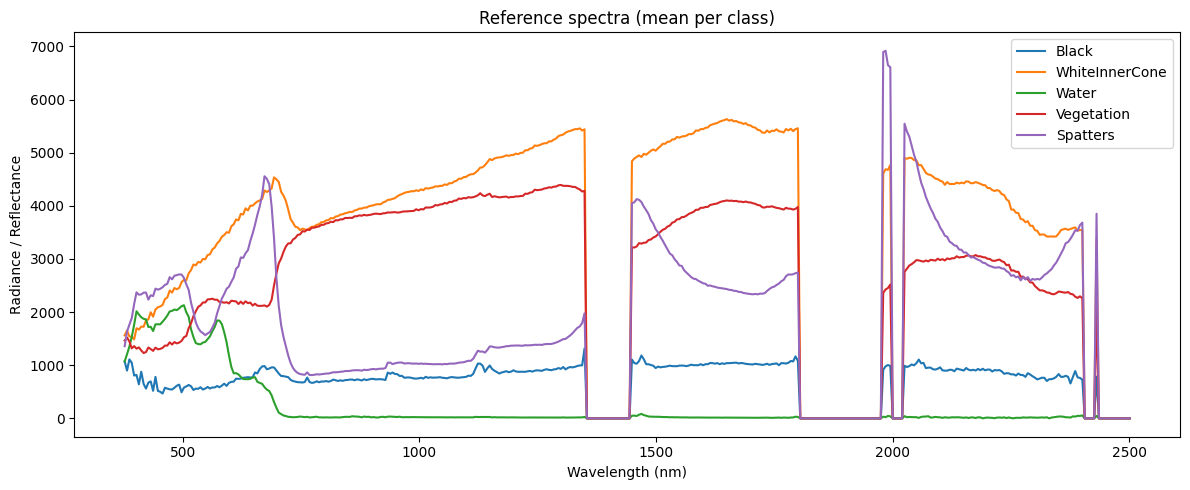

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
for i, name in enumerate(CLASS_NAMES):
    plt.plot(img_wavelengths, aligned_refs[i], label=name, linewidth=1.5)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Radiance / Reflectance')
plt.title('Reference spectra (mean per class)')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Load image and get wavelengths (if not already done)
flat = data.reshape(-1, bands)

# Define bad wavelength ranges
bad_ranges = [(677, 754), (1348, 1463), (1799, 1974)]
good_bands = [i for i, wl in enumerate(img_wavelengths) if not any(lo <= wl <= hi for lo, hi in bad_ranges)]

flat_clean = flat[:, good_bands]
refs_clean = (aligned_refs / 10000.0)[:, good_bands]

print(f"Total bands: {bands}, Good bands after removal: {len(good_bands)}")
print("flat_clean range:", flat_clean.min(), flat_clean.max())
print("refs_clean range:", refs_clean.min(), refs_clean.max())

Total bands: 425, Good bands after removal: 351
flat_clean range: -3.2603 3.2226
refs_clean range: 0.0 0.691976171875


Unique labels: [1 2 3 4 5]
Sample distances: [[0.65681834 0.70836904 0.01530858 0.7498887  0.58985616]
 [0.66712898 0.71992496 0.01150984 0.75907198 0.60625358]
 [0.66850436 0.71726881 0.01705482 0.7577305  0.60328804]]


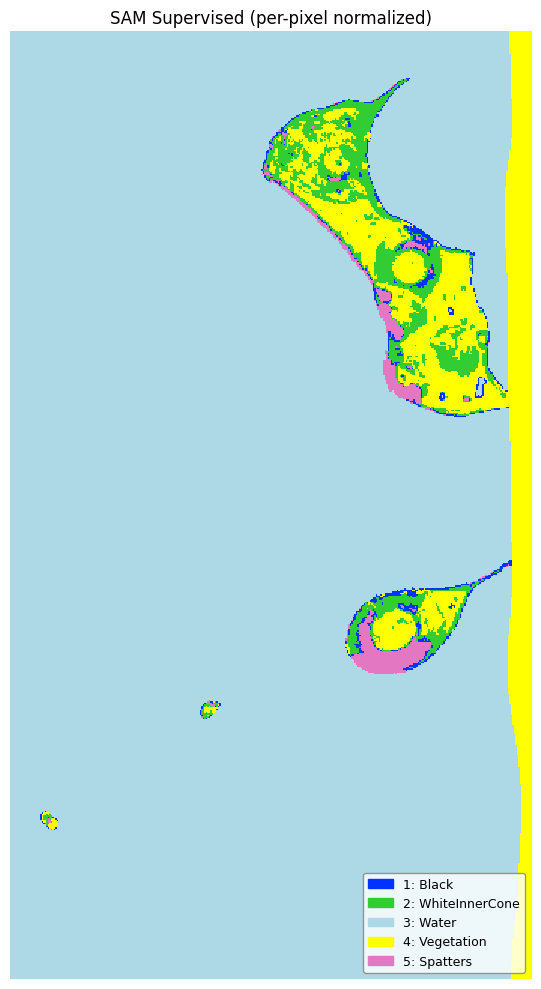

In [24]:
from scipy.spatial.distance import cdist
from matplotlib.colors import BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# Normalize flat_clean per pixel (same as kmeans)
flat_norm  = flat_clean.copy()
pixel_mean = flat_norm.mean(axis=1, keepdims=True)
pixel_mean[pixel_mean == 0] = 1
flat_norm  = flat_norm / pixel_mean

# Normalize refs the same way
refs_norm  = refs_clean.copy()
ref_mean   = refs_norm.mean(axis=1, keepdims=True)
ref_mean[ref_mean == 0] = 1
refs_norm  = refs_norm / ref_mean

# SAM classification
cos_dist  = cdist(flat_norm, refs_norm, metric='cosine')
labels    = np.argmin(cos_dist, axis=1).astype(np.uint8) + 1
classified = labels.reshape(rows, cols)
print("Unique labels:", np.unique(classified))
print("Sample distances:", cos_dist[:3])

# Plot
n_classes = len(CLASS_NAMES)
colors  = ['#0033FF', '#32CD32', 'Lightblue', '#FFFF00', '#e377c2']
cmap    = plt.matplotlib.colors.ListedColormap(colors)
norm    = BoundaryNorm(np.arange(0.5, n_classes + 1.5), n_classes)
patches = [mpatches.Patch(color=colors[i], label=f'{i+1}: {CLASS_NAMES[i]}')
           for i in range(n_classes)]

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(classified, cmap=cmap, norm=norm, interpolation='nearest')
ax.legend(handles=patches, loc='lower right', fontsize=9,
          facecolor='white', edgecolor='gray')
ax.set_title('SAM Supervised (per-pixel normalized)')
ax.axis('off')
plt.tight_layout()
plt.show()